In [ ]:
# Set A

In [ ]:
# Text Preprocessing and Extractive Summarization
#1

In [1]:
import nltk
import re
import heapq
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [2]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/tycs14/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/tycs14/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
# Input paragraph
text = """The global shift toward renewable energy is no longer just an environmental goal; it has become an economic and geopolitical necessity. 
As fossil fuel reserves continue to deplete and the impact of climate change becomes more severe, 
nations are racing to modernize their power grids with sustainable alternatives. Solar and wind energy have emerged as the primary 
frontrunners in this transition due to their rapidly falling costs and increasing efficiency. However, the intermittent nature of these 
sources—where the sun doesn't always shine and the wind doesn't always blow—remains one of the most significant technical hurdles to overcome.
To address these challenges, engineers and scientists are focusing heavily on advanced energy storage technologies. 
Large-scale lithium-ion battery arrays and emerging solid-state batteries are being deployed to store excess energy during peak 
production hours for use during times of low generation. Furthermore, the integration of artificial intelligence into 'smart grids' allows for 
real-time monitoring and distribution of electricity, ensuring that supply meets demand with minimal waste. This digital layer of the energy transition 
is just as critical as the physical hardware of solar panels and wind turbines.
Despite these advancements, the transition to a fully green economy faces political and infrastructural roadblocks. 
Many existing power plants were built decades ago and are not easily compatible with decentralized energy sources. 
Additionally, the mining of rare earth minerals required for high-tech batteries raises new environmental and ethical concerns. 
Ultimately, the success of the renewable energy revolution will depend on a combination of innovative policy-making, massive infrastructure investment, 
and a global commitment to reducing carbon footprints. The path forward is complex, but the potential for a cleaner, 
more resilient energy future is within reach."""

In [ ]:
# Remove stopwords
stopWords = set(stopwords.words("english"))

wordfreq = {}

for word in words:
    if word not in stopWords:
        if word in wordfreq:
            wordfreq[word] += 1
        else:
            wordfreq[word] = 1

print(wordfreq)

In [ ]:
# Calculate weighted frequency
maximum_frequency = max(wordfreq.values())

for word in wordfreq.keys():
    wordfreq[word] = wordfreq[word] / maximum_frequency

In [2]:
# Tokenize sentences
sentences = sent_tokenize(text)

sentence_scores = {}

for sentence in sentences:
    for word in word_tokenize(sentence.lower()):
        if word in wordfreq:
            if sentence in sentence_scores:
                sentence_scores[sentence] += wordfreq[word]
            else:                    
                sentence_scores[sentence] = wordfreq[word]

print(sentence_scores)

NameError: name 'sent_tokenize' is not defined

In [1]:
# Generate summary (top 3 sentences)
top_sentences = heapq.nlargest(3, sentence_scores, key=sentence_scores.get)

# Sort them based on where they appeared in the original 'sentences' list
summary_sentences = sorted(top_sentences, key=lambda x: text.find(x))

summary = ' '.join(summary_sentences)

print("\nOriginal Text:\n", text)
print("\nSummary:\n", summary)

NameError: name 'heapq' is not defined

In [ ]:
# Sentiment Analysis using VADER
#3

In [ ]:
import nltk
import re
import heapq
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize

In [8]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/tycs14/nltk_data...


True

In [4]:
sia = SentimentIntensityAnalyzer()

In [7]:
reviews = [
    "Absolutely fantastic experience! The [product] is top-quality, durable, and easy to use. Highly recommended for anyone looking for a reliable solution.",
    "I saw the movie yesterday. The animation was really good but the script was ok.",
    "The plot of the movie was unpredictable.",
    "The package arrived on Tuesday. It is a standard size and the color matches the description.",
    "I love the sleek design of this phone, but the battery life is absolutely pathetic.",
    "Unless you enjoy wasting your time, stay away from this service.",  # Negative review but flagged as positive by VADER
    "Terrible experience. The item arrived broken and customer support was completely unhelpful."
]
for review in reviews:
    score = sia.polarity_scores(review)

    print("\nMessage:", review)
    print("Score:", score)

    if score['compound'] >= 0.05:
        print("Sentiment: Positive")

    elif score['compound'] <= -0.05:
        print("Sentiment: Negative")

    else:
        print("Sentiment: Neutral")


Message: Absolutely fantastic experience! The [product] is top-quality, durable, and easy to use. Highly recommended for anyone looking for a reliable solution.
Score: {'neg': 0.0, 'neu': 0.582, 'pos': 0.418, 'compound': 0.888}
Sentiment: Positive

Message: I saw the movie yesterday. The animation was really good but the script was ok.
Score: {'neg': 0.0, 'neu': 0.71, 'pos': 0.29, 'compound': 0.5989}
Sentiment: Positive

Message: The plot of the movie was unpredictable.
Score: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Sentiment: Neutral

Message: The package arrived on Tuesday. It is a standard size and the color matches the description.
Score: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Sentiment: Neutral

Message: I love the sleek design of this phone, but the battery life is absolutely pathetic.
Score: {'neg': 0.273, 'neu': 0.597, 'pos': 0.129, 'compound': -0.598}
Sentiment: Negative

Message: Unless you enjoy wasting your time, stay away from this service.
Sc

In [16]:
# Stopwords Removal, Frequency Distribution, and WordCloud
#2

In [17]:
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from wordcloud import WordCloud

In [10]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/tycs14/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/tycs14/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [19]:
text = """In the modern era of rapid technological advancement, the concept of intelligence is undergoing a profound transformation. 
While traditional forms of intelligence were once defined solely by human cognitive abilities, 
the rise of artificial intelligence has expanded our understanding of what it means to be 'smart.' 
This new intelligence is not a replacement for human potential but rather a powerful extension of it.
The future of technology depends on the seamless integration of human intuition and digital intelligence. 
As we look toward the future, we see that technology is no longer just a tool; it is a fundamental part of the human experience. 
We must ask ourselves: how will this technology shape the future of our society? Will the future be dominated by machines, 
or will human creativity remain the driving force?
Every day, new technology emerges, challenging our old perspectives. This constant evolution of technology requires us to refine 
our own intelligence to keep pace. The intersection of human life and technology is where the most significant innovations occur. 
To prepare for the future, we must embrace both the challenges and the opportunities that this digital intelligence provides. 
Ultimately, the future is not something that just happens to us; it is something we build with the intelligence and technology available to us today. 
By focusing on the human element, we ensure that the future of technology serves the best interests of all human beings."""

In [20]:
# Tokenize words
words = word_tokenize(text.lower())

In [21]:
# Remove stopwords
stopWords = set(stopwords.words("english"))

filtered_words = [word for word in words if word.isalpha() and word not in stopWords]

In [22]:
# Frequency Distribution
fdist = FreqDist(filtered_words)

print("\nWord Frequency:")
print(fdist)


Word Frequency:
<FreqDist with 89 samples and 122 outcomes>


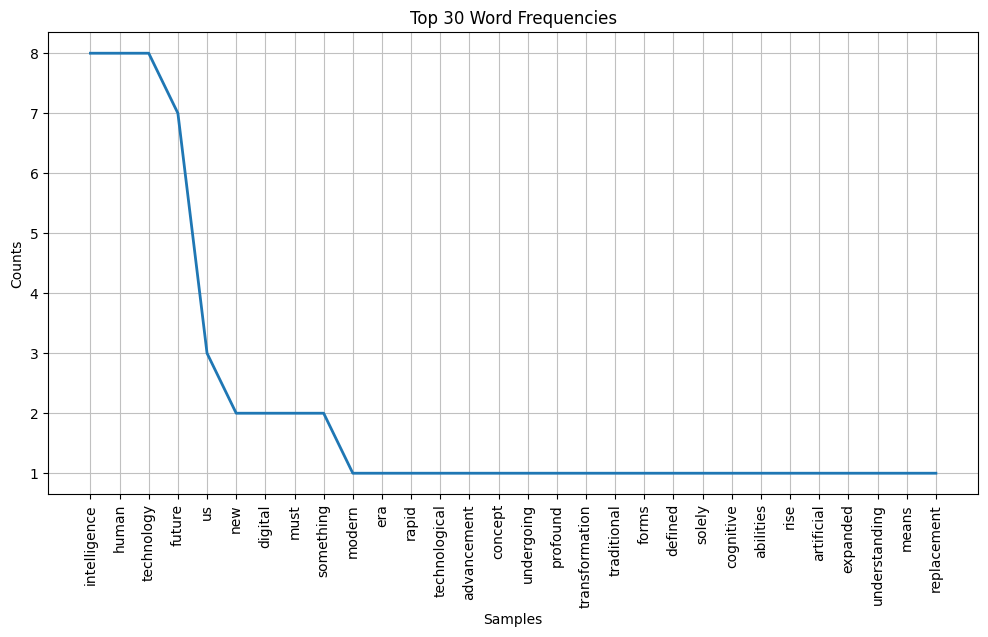

In [23]:
# Plot frequency graph
plt.figure(figsize=(12, 6))
plt.title("Top 30 Word Frequencies")
fdist.plot(30, cumulative=False)
plt.show()

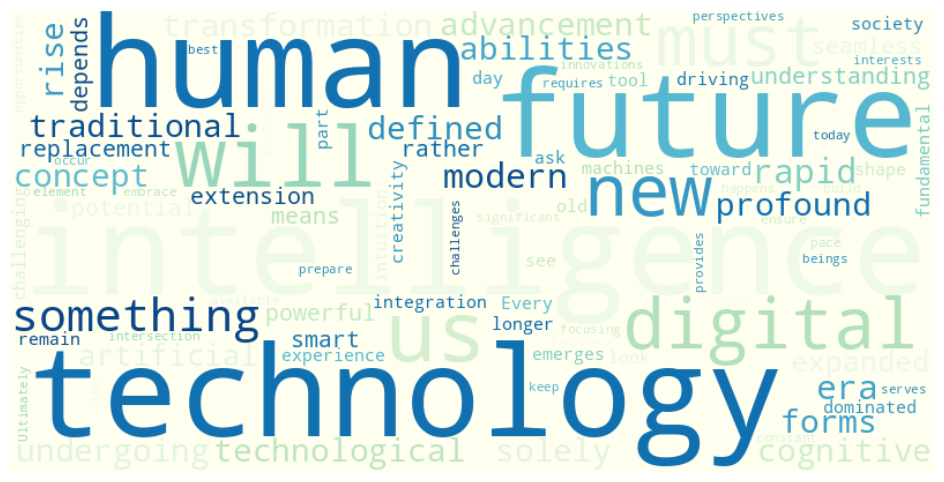

In [28]:
# Generate WordCloud

# Using 'ivory' background and 'GnBu' (Green-Blue) colormap for a calming effect
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='ivory', 
    colormap='GnBu',           
    max_words=100
).generate(text)

plt.figure(figsize=(12, 6))

plt.imshow(wordcloud, interpolation='bilinear') 

plt.axis("off")
plt.show()

In [29]:
# WhatsApp Chat Text Analytics
#4

In [30]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [12]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/tycs14/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/tycs14/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [32]:
with open("/home/tycs14/whatsapp_chat.txt", "r", encoding="utf-8") as file:
    text = file.read()

In [33]:
# Basic Tokenization
sentences = sent_tokenize(text)
words = word_tokenize(text.lower())

In [34]:
# Enhanced Filtering
# Added 'omitted' and 'media' because WhatsApp marks images as <Media omitted>
additional_junk = {'media', 'omitted', 'message', 'pm', 'am'}
stopWords = set(stopwords.words("english")).union(additional_junk)

# Add names to stopwords so they don't dominate the WordCloud
names = {'joel', 'chris'}
stopWords = set(stopwords.words("english")).union(additional_junk).union(names)

# Filter out non-alpha words (removes timestamps/dates) and stopwords
filtered_words = [word for word in words if word.isalpha() and word not in stopWords]

print(f"\nTotal words after filtering: {len(filtered_words)}")


Total words after filtering: 57


In [35]:
# Generate WordCloud 
# Using 'ivory' background and 'GnBu' colormap
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='ivory', 
    colormap='GnBu',
    max_words=150,
    collocations=False  # Prevents repeating word pairs
).generate(" ".join(filtered_words))

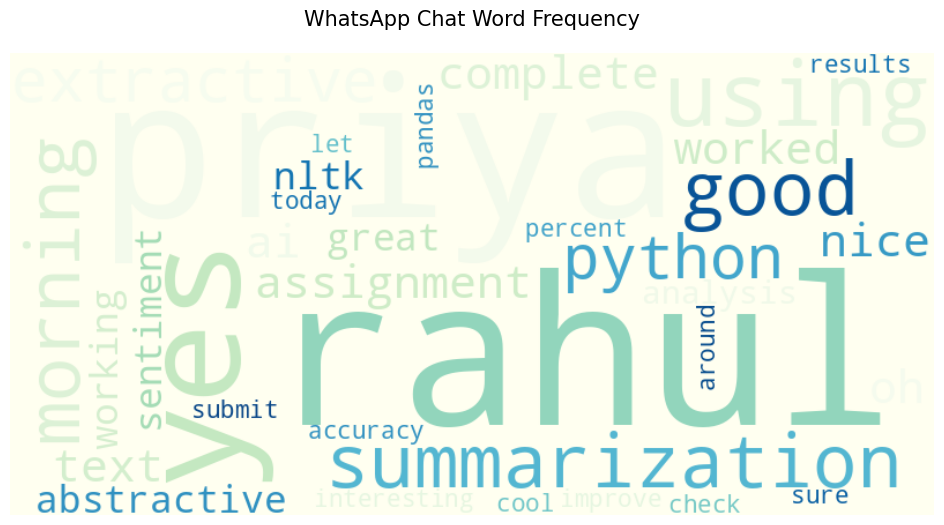

In [36]:
# Plotting with smooth interpolation
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("WhatsApp Chat Word Frequency", fontsize=15, pad=20)
plt.show()

In [38]:
# Set B

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

In [13]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/tycs14/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [39]:
# Load dataset
df = pd.read_csv("/home/tycs14/top_1000_instagrammers.csv")

print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Name                  1000 non-null   str  
 1   Rank                  1000 non-null   int64
 2   Category              916 non-null    str  
 3   Followers             1000 non-null   str  
 4   Audience Country      986 non-null    str  
 5   Authentic Engagement  1000 non-null   str  
 6   Engagement Avg.       1000 non-null   str  
dtypes: int64(1), str(6)
memory usage: 54.8 KB
None


In [40]:
# 1. Top 5 Influencers from India
india_df = df[df['Audience Country'] == 'India']
top5_india = india_df.sort_values(by='Followers', ascending=False).head(5)

print("\nTop 5 Influencer's Audience from India:")
print(top5_india[['Name', 'Followers']])


Top 5 Influencer's Audience from India:
                  Name Followers
637          jaspritb1      9.8M
680            djsnake      9.6M
101            yawnzzn      9.6M
627            djsnake      9.5M
628  kareenakapoorkhan      9.4M


In [41]:
# 2. Account with Least Followers
least_followers = df.sort_values(by='Followers', ascending=True).head(1)

print("\nAccount with Least Followers:")
print(least_followers[['Name', 'Followers']])


Account with Least Followers:
                    Name Followers
772  la_beaute_africaine      1.6M


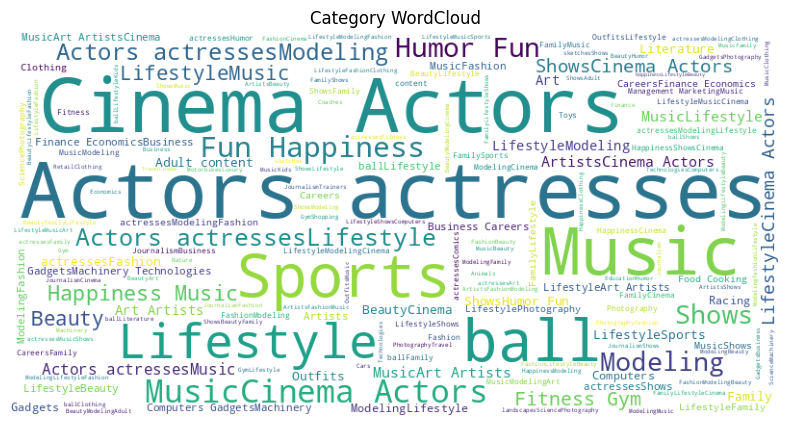

In [42]:
# 3. Wordcloud from Category column
stop_words = set(stopwords.words("english"))

category_text = " ".join(df['Category'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color='white',
                      stopwords=stop_words).generate(category_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Category WordCloud")
plt.show()

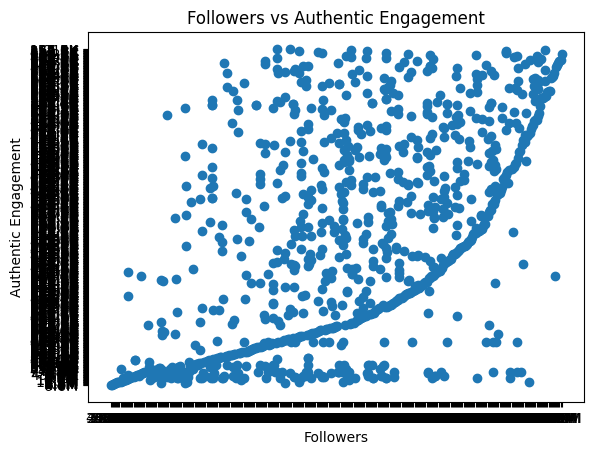

In [43]:
# 5. Plot Followers vs Authentic Engagement
plt.scatter(df['Followers'], df['Engagement Avg.'])
plt.xlabel("Followers")
plt.ylabel("Authentic Engagement")
plt.title("Followers vs Authentic Engagement")
plt.show()

In [49]:
# 3

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
# Load dataset
df = pd.read_csv("/home/tycs14/INvideos.csv",
                engine="python",
                on_bad_lines="skip"
)

In [47]:
# Data Cleaning
df.dropna(inplace=True)

# Convert publish_time to datetime
df['publish_time'] = pd.to_datetime(df['publish_time'])

# Extract year
df['year'] = df['publish_time'].dt.year

In [48]:
# 1. Total views, likes, dislikes, comments
print("\nTotal Views:", df['views'].sum())
print("Total Likes:", df['likes'].sum())
print("Total Dislikes:", df['dislikes'].sum())
print("Total Comments:", df['comment_count'].sum())


Total Views: 545735840
Total Likes: 13215814
Total Dislikes: 663218
Total Comments: 1385373


In [49]:
# 2. Most liked video
most_liked = df.sort_values(by='likes', ascending=False).head(1)
print("\nMost Liked Video:")
print(most_liked[['title', 'likes']])

# Least liked video
least_liked = df.sort_values(by='likes', ascending=True).head(1)
print("\nLeast Liked Video:")
print(least_liked[['title', 'likes']])


Most Liked Video:
                                           title    likes
377  Ed Sheeran - Perfect (Official Music Video)  1721384

Least Liked Video:
                                                title  likes
691  16 November, 2017 Prelim Booster News Discussion      0


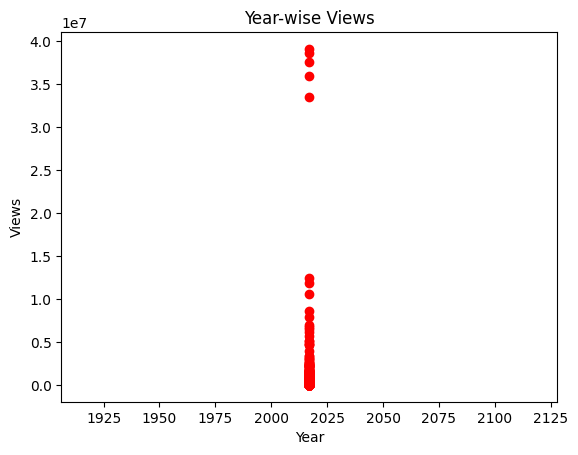

In [50]:
# 3. Year-wise Views Plot
plt.scatter(df['year'], df['views'], color="red")
plt.xlabel("Year")
plt.ylabel("Views")
plt.title("Year-wise Views")
plt.show()

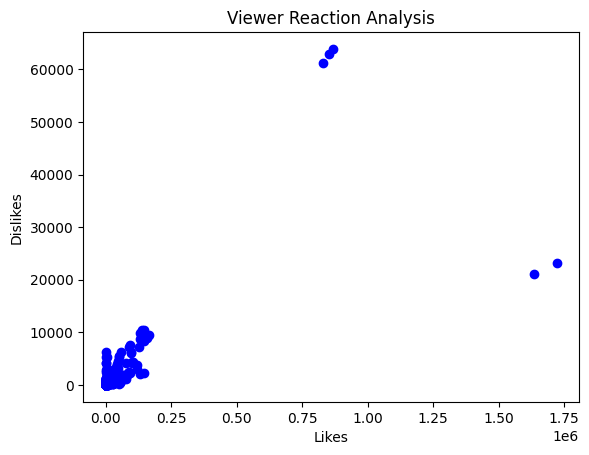

In [51]:
# 4. Viewer Reaction Plot
plt.scatter(df['likes'], df['dislikes'], color="blue")
plt.xlabel("Likes")
plt.ylabel("Dislikes")
plt.title("Viewer Reaction Analysis")
plt.show()